# 11 · Visualization Gallery

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/11_visualization.ipynb)

Publication-quality figures the project can produce: device-state panels, I–V with uncertainty, recovered-doping overlays. Suitable for GitHub, slides, and the paper.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate, SurrogateEnsemble)
symlog=SymlogTransform(I0=1e-6); biases=np.linspace(0.0,0.6,21)
profiles=[step(L) for L in np.geomspace(5e20,5e22,11)]
X,Y=build_sg_dataset(profiles,np.linspace(0,0.6,13),scaling,sg,symlog); norm=Normalizer.fit(X)
members=[IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR,hidden=128,n_layers=3,seed=m)) for m in range(5)]
for m,net in enumerate(members):
    rs=np.random.RandomState(m); idx=rs.randint(0,len(X),len(X)); train_surrogate(net,X[idx],Y[idx],norm,epochs=1500,lr=2e-3)
ens=SurrogateEnsemble(members,norm,symlog)


## Device-state panel (SG)

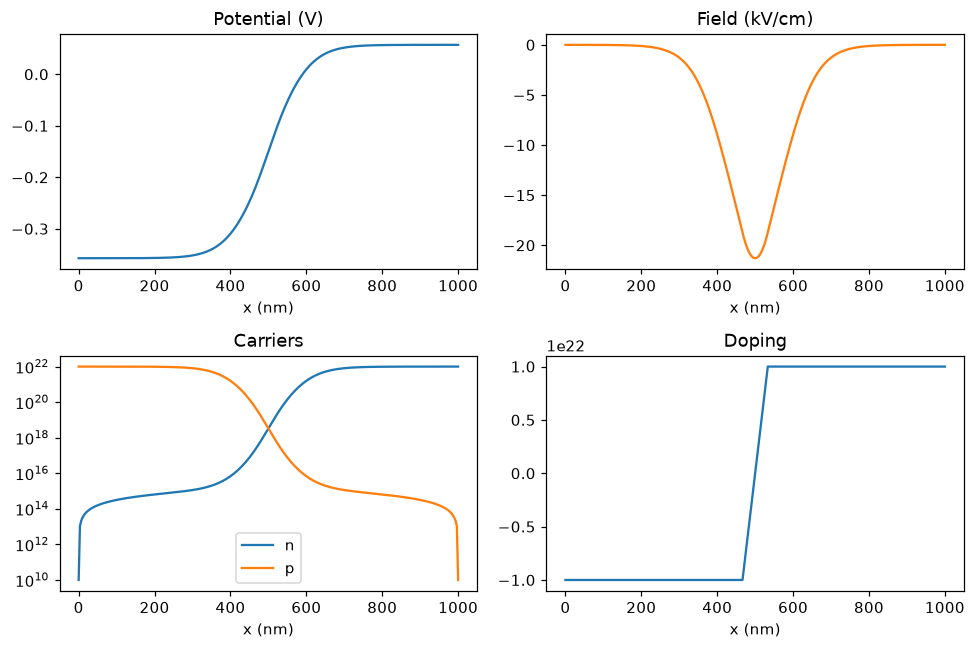

In [3]:

st=sg.solve(step(1e22),0.3); x_nm=np.linspace(0,1000,len(st.phi))
fig,ax=plt.subplots(2,2,figsize=(9,6))
ax[0,0].plot(x_nm,st.phi); ax[0,0].set_title("Potential (V)")
ax[0,1].plot(x_nm,-np.gradient(st.phi,x_nm*1e-9)/1e5,c="C1"); ax[0,1].set_title("Field (kV/cm)")
ax[1,0].semilogy(x_nm,np.abs(st.n)+1,label="n"); ax[1,0].semilogy(x_nm,np.abs(st.p)+1,label="p"); ax[1,0].legend(); ax[1,0].set_title("Carriers")
ax[1,1].plot(x_nm, st.doping if hasattr(st,'doping') else np.where(x_nm<500,-1e22,1e22)); ax[1,1].set_title("Doping")
for a in ax.ravel(): a.set_xlabel("x (nm)")
plt.tight_layout(); plt.show()


## I–V with ensemble uncertainty band

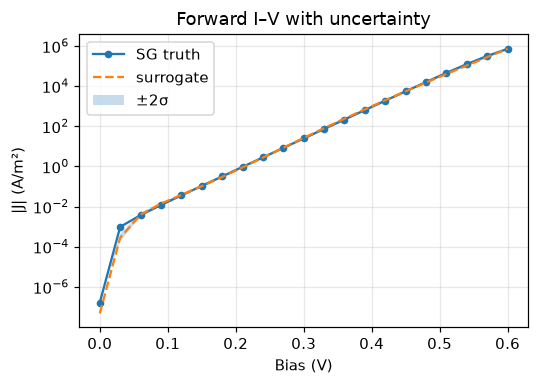

In [4]:

C=step(1.7e21); pred=ens.predict(scaling.doping_to_net_input(C), biases/VT)
lo=symlog.inverse(pred.mean_symlog-2*pred.std_symlog); hi=symlog.inverse(pred.mean_symlog+2*pred.std_symlog)
Isg=sg_iv(C,biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases,np.abs(Isg),"o-",label="SG truth",ms=4)
plt.semilogy(biases,np.abs(pred.mean_current),"--",label="surrogate")
plt.fill_between(biases,np.abs(lo),np.abs(hi),alpha=0.25,label="±2σ")
plt.legend(); plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.grid(alpha=0.3)
plt.title("Forward I–V with uncertainty"); plt.tight_layout(); plt.show()
